In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [50]:
import math
def get_width(cluster):
    point_1 = cluster['low']
    point_2 = [cluster['high'][0], cluster["low"][1]]
    return math.sqrt(math.pow(point_1[0] - point_2[0], 2) + math.pow(point_1[1] - point_2[1], 2))

def get_height(cluster):
    point_3 = [cluster['low'][0], cluster['high'][1]]
    point_1 = cluster['low']
    return math.sqrt(math.pow(point_1[0] - point_3[0], 2) + math.pow(point_1[1] - point_3[1], 2))

In [51]:
def get_coordinates(clusters):
    coordinates = []
    for cluster in clusters:
        left, width = cluster['low'][0], get_width(cluster)
        bottom, height = cluster['low'][1], get_height(cluster)
        mean = cluster['mean']

        right = left + width
        top = bottom + height

        coordinates.append({"left": left, "width": width, "bottom": bottom, "height": height, "right": right, "top": top, "mean": mean})
    return coordinates

In [52]:
def plot_rectangles(clusters: list):
    # build a rectangle in axes coords
    colors = "bgrcmykw"
    handles = []
    coordinates = get_coordinates(clusters)
    clusters = list(map(lambda x: f'Cluster {x["cluster"]}', clusters))
    _, ax = plt.subplots()

    for index, coor in enumerate(coordinates):
        left = coor['left']
        bottom = coor['bottom']
        width = coor['width']
        height = coor['height']
        right = coor['right']
        top = coor['top']
        mean = coor['mean']

        ax.plot(mean[0], mean[1], 'o', color=colors[index])

        p = patches.Rectangle(
                (left, bottom), width, height,
                linestyle = 'dashed',
                fill=False, clip_on=False,
                color=colors[index]
                )

        ax.add_patch(p)

        ax.text(left, bottom, 'min',
                horizontalalignment='left',
                verticalalignment='top')

        ax.text(right, top, 'max',
                horizontalalignment='right',
                verticalalignment='bottom')

        # ax.text(0.5*(left+right), 0.5*(bottom+top), 'mean',
        #         horizontalalignment='center',
        #         verticalalignment='center',
        #         color=colors[index])
        handles.append(p)

    # ax.set_axis_off()
    plt.legend(handles=handles, labels = clusters)
    plt.show()

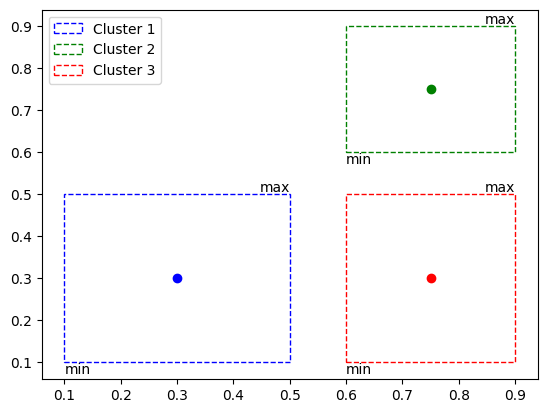

In [53]:
clusters = [
    {"low": [0.1, 0.1], "high": [0.5, 0.5], "mean": [0.3, 0.3], "cluster": 1},
    {"low": [0.6, 0.6], "high": [0.9, 0.9], "mean": [0.75, 0.75], "cluster": 2},
    {"low": [0.6, 0.1], "high": [0.9, 0.5], "mean": [0.75, 0.3], "cluster": 3}
]
plot_rectangles(clusters)